Best k is: 45


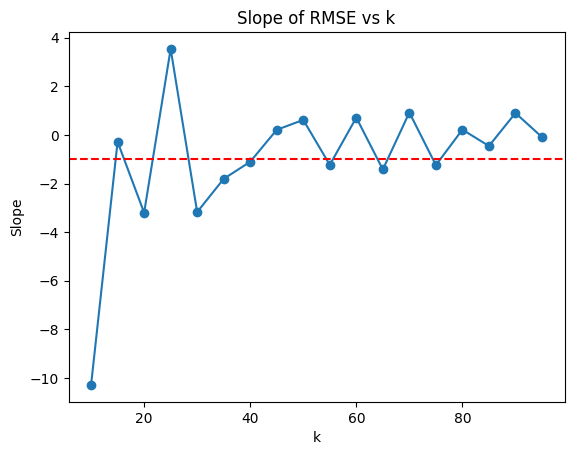

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Get data for k and MSE values
ks = range(10, 105, 5)
mses = {10: np.float64(0.5819755183754586), 15: np.float64(0.29809714904145046), 
20: np.float64(0.2902909942570982), 25: np.float64(0.2019825146042987), 
30: np.float64(0.2996143228475176), 35: np.float64(0.21201014145333502), 
40: np.float64(0.1621252522600909), 45: np.float64(0.1316499985612603), 
50: np.float64(0.13744606272403417), 55: np.float64(0.1544768837991384), 
60: np.float64(0.12044136261975785), 65: np.float64(0.14008067366201815), 
70: np.float64(0.10080972883008701), 75: np.float64(0.12624587105542576), 
80: np.float64(0.09193690120183368), 85: np.float64(0.0979061414143483), 
90: np.float64(0.08530692431161503), 95: np.float64(0.11014746879873467), 
100: np.float64(0.10764834570958784)}
mse_values = [mses[k] for k in ks]

# Compute the normalized values
mse_range = max(mse_values) - min(mse_values)
k_range = max(ks) - min(ks)
mse_values_normalized = [(mse - min(mse_values)) / mse_range for mse in mse_values]
k_normalized = [(k - min(ks)) / k_range for k in ks]

# compute the slope between each pair of consecutive points
slopes = [(mse_values_normalized[i+1] - mse_values_normalized[i]) / (k_normalized[i+1] - k_normalized[i]) for i in range(len(mse_values)-1)]

# find the k value where the slope is over -1 (if we leave out the first few values)
beest_k = None
for i in range(len(slopes)):
    if slopes[i] > -1 and ks[i] != 25 and ks[i] != 15:
        beest_k = ks[i]
        break
print("Best k is:",beest_k)
plt.plot(ks[:-1], slopes, marker='o')
plt.title('Slope of RMSE vs k')
plt.xlabel('k')
plt.ylabel('Slope')
plt.axhline(y=-1, color='r', linestyle='--')
plt.show()

Text(0, 0.5, 'RMSE')

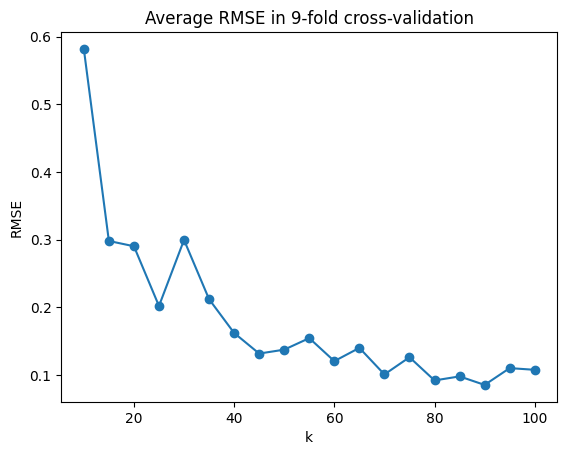

In [11]:
plt.plot(ks, mse_values, marker='o')
plt.title('Average RMSE in 9-fold cross-validation')
plt.xlabel('k')
plt.ylabel('RMSE')